In [1]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# ============================================================
# 2️⃣ LOAD & PREPROCESS MULTI-YEAR NSE DATASET
# ============================================================

df = pd.read_csv("NIFTY_4_Years.csv", encoding="utf-8-sig")

# Clean columns
df.columns = df.columns.str.strip()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort ascending
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

# Use Close price
data = df[['Close']]

# Train-Test Split (80-20)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print("Training size:", len(train))
print("Testing size :", len(test))

Training size: 795
Testing size : 199


In [3]:
# ============================================================
# 3️⃣ SCALING FOR DEEP LEARNING
# ============================================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [4]:
# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2


time_steps = 60

In [5]:
# ==============================
# ARIMA + LSTM (Safe + Corrected)
# ==============================

time_steps = 20

# --- ARIMA ---
arima_model = ARIMA(train['Close'], order=(3,1,1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - arima_forecast.values
residuals = residuals.reshape(-1,1)

# Check if enough data
if len(residuals) <= time_steps:
    print("Not enough test data for LSTM residual modeling.")
    
    # Avoid NameError later
    rmse1, mae1, r21 = None, None, None

else:
    # --- Scale residuals ---
    res_scaler = MinMaxScaler()
    res_scaled = res_scaler.fit_transform(residuals)

    # --- Create sequences ---
    X_res, y_res = create_sequences(res_scaled, time_steps)

    print("Residual sequence shape:", X_res.shape)

    # --- LSTM Model ---
    model1 = Sequential()
    model1.add(LSTM(64, activation='relu', input_shape=(time_steps,1)))
    model1.add(Dense(1))

    model1.compile(optimizer='adam', loss='mse')

    model1.fit(X_res, y_res, epochs=30, batch_size=32, verbose=0)

    # --- Predict residuals ---
    lstm_res_pred = model1.predict(X_res)
    lstm_res_pred = res_scaler.inverse_transform(lstm_res_pred)

    # --- Final hybrid prediction ---
    final_arima_lstm = arima_forecast[time_steps:].values + lstm_res_pred.flatten()

    actual1 = test['Close'].values[time_steps:]

    # --- Store metrics correctly ---
    rmse1, mae1, r21 = evaluate_model(actual1, final_arima_lstm, "ARIMA + LSTM")

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Residual sequence shape: (179, 20, 1)



C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(




6/6 [==============================] - 0s 3ms/step

ARIMA + LSTM
RMSE: 344.1706223194503
MAE : 291.74681877568986
R2  : 0.8000912686410988


## for arima Tuning tune (p,d,q) 
change order=(3,1,1) to like (1,1,1) or (2,1,2)or (5,1,0) or (5,1,2) or (7,1,3)
then compare using print(arima_result.aic) and print(arima_result.bic) Pick the order with lowest AIC/BIC.

## for LSTM tuning above : 
model1 = Sequential()
model1.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model1.add(Dropout(0.2))
model1.add(LSTM(64))
model1.add(Dropout(0.2))
model1.add(Dense(1)) 

activation tanh 
different batch size
instead of MinMaxScaler() use StandardScaler()

In [6]:
# ============================================================
# SARIMA + LSTM
# ============================================================

sarima_model = SARIMAX(train['Close'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.forecast(steps=len(test))

residuals_s = test['Close'].values - sarima_forecast.values
residuals_s = residuals_s.reshape(-1,1)

res_scaler_s = MinMaxScaler()
res_scaled_s = res_scaler_s.fit_transform(residuals_s)

X_res_s, y_res_s = create_sequences(res_scaled_s, time_steps)

model2 = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps,1)),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.fit(X_res_s, y_res_s, epochs=30, batch_size=32, verbose=0)

lstm_res_pred_s = model2.predict(X_res_s)
lstm_res_pred_s = res_scaler_s.inverse_transform(lstm_res_pred_s)

final_sarima_lstm = sarima_forecast[time_steps:].values + lstm_res_pred_s.flatten()
actual2 = test['Close'].values[time_steps:]

rmse2, mae2, r22 = evaluate_model(actual2, final_sarima_lstm, "SARIMA + LSTM")

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

6/6 [==============================] - 0s 3ms/step

SARIMA + LSTM
RMSE: 331.21898161188363
MAE : 273.152162430306
R2  : 0.8148538848176048


## For Sarima + LSTM Tuning : 
seasinal peroid change : seasonal_order=(1,1,1,5)     # Weekly trading cycle
seasonal_order=(1,1,1,21)    # Monthly trading cycle
seasonal_order=(0,1,1,5)
seasonal_order=(1,0,1,5)

tune (p,d,q) : (1,1,1)
(2,1,2)
(3,1,1)
(5,1,2)

after fitting : print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) choose lowset aic bic

LSTM(64, activation='relu')
epochs=30

increase time steps : time_steps = 20

better LSTM architecture : model2 = Sequential()
model2.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model2.add(Dropout(0.2))
model2.add(LSTM(64))
model2.add(Dropout(0.2))
model2.add(Dense(1))

activation tanh

StandardScaler() instead of MinMaxScaler()



In [7]:
# ============================================================
# RNN + LSTM
# ============================================================

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

model3 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps,1)),
    LSTM(64),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

rnn_lstm_pred = model3.predict(X_test)
rnn_lstm_pred = scaler.inverse_transform(rnn_lstm_pred)
actual3 = scaler.inverse_transform(y_test)

rmse3, mae3, r23 = evaluate_model(actual3, rnn_lstm_pred, "RNN + LSTM")

6/6 [==============================] - 1s 4ms/step

RNN + LSTM
RMSE: 264.5286619408742
MAE : 216.6277736557263
R2  : 0.8819055088535657


## RNN + LSTM Tuning
Increase Model Capacity : model3 = Sequential()

model3.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model3.add(Dropout(0.2))

model3.add(LSTM(128, return_sequences=True))
model3.add(Dropout(0.2))

model3.add(LSTM(64))
model3.add(Dropout(0.2))

model3.add(Dense(1))

INcrease time Steps : time_steps = 20 tp 30 60 or 90

activation tanh different batch size instead of MinMaxScaler() use StandardScaler()

In [8]:
# ============================================================
# SARIMA + RNN
# ============================================================

residuals2 = test['Close'].values - sarima_forecast.values
residuals2 = residuals2.reshape(-1,1)

res_scaler2 = MinMaxScaler()
res_scaled2 = res_scaler2.fit_transform(residuals2)

X_res2, y_res2 = create_sequences(res_scaled2, time_steps)

model4 = Sequential([
    SimpleRNN(64, input_shape=(time_steps,1)),
    Dense(1)
])

model4.compile(optimizer='adam', loss='mse')
model4.fit(X_res2, y_res2, epochs=30, batch_size=32, verbose=0)

rnn_res_pred = model4.predict(X_res2)
rnn_res_pred = res_scaler2.inverse_transform(rnn_res_pred)

final_sarima_rnn = sarima_forecast[time_steps:].values + rnn_res_pred.flatten()
actual4 = test['Close'].values[time_steps:]

rmse4, mae4, r24 = evaluate_model(actual4, final_sarima_rnn, "SARIMA + RNN")

6/6 [==============================] - 0s 2ms/step

SARIMA + RNN
RMSE: 287.47422287480094
MAE : 225.584857598869
R2  : 0.8605296193756635


## FOr SARIMA + RNN Tuning : 
seasonal_order=(1,1,1,5)   # Weekly trading cycle try seasonal_order=(1,1,1,5)   # Weekly trading cycle

print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) LOwer is better

Increase RNN Depth : model4 = Sequential()

model4.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model4.add(Dropout(0.2))

model4.add(SimpleRNN(64))
model4.add(Dropout(0.2))

model4.add(Dense(1))


tune time steps : time_steps = 20 to 30 or 60 or 90

tune optimizer : from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model4.compile(optimizer=optimizer, loss='mse')

change loss function : loss='huber'

standardSclaer insted of MinMaxScaler()



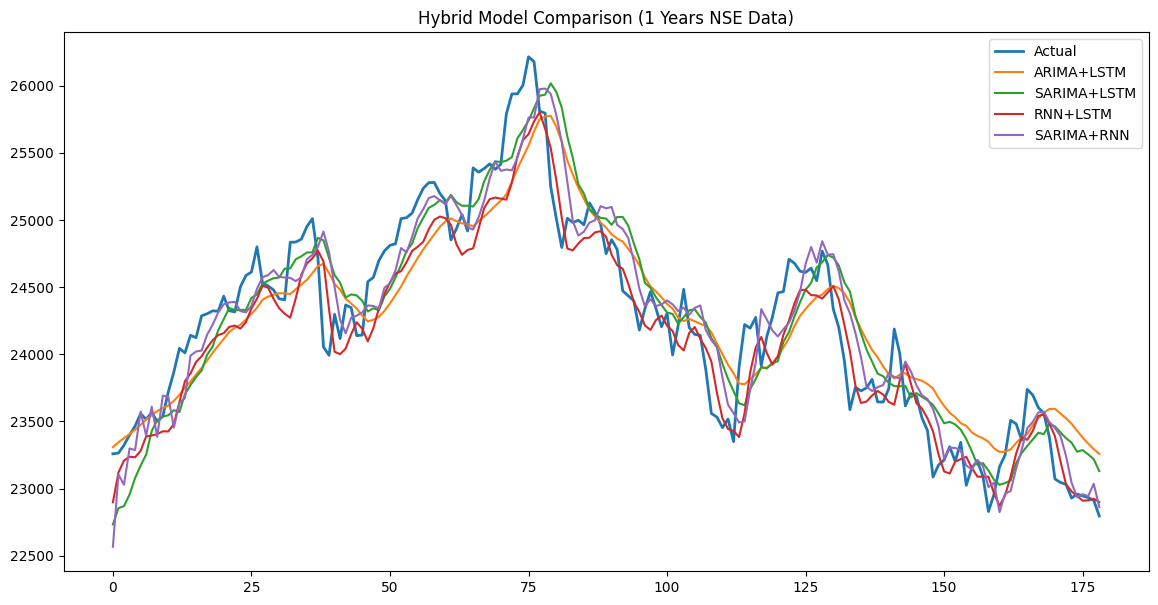

In [9]:
plt.figure(figsize=(14,7))

plt.plot(actual1, label="Actual", linewidth=2)
plt.plot(final_arima_lstm, label="ARIMA+LSTM")
plt.plot(final_sarima_lstm, label="SARIMA+LSTM")
plt.plot(rnn_lstm_pred, label="RNN+LSTM")
plt.plot(final_sarima_rnn, label="SARIMA+RNN")

plt.legend()
plt.title("Hybrid Model Comparison (1 Years NSE Data)")
plt.show()

In [10]:
def evaluate_model_advanced(actual, predicted, model_name):
    
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    
    # Errors
    errors = actual - predicted
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs(errors / actual)) * 100
    
    # Volatility (returns std deviation)
    returns_actual = np.diff(actual) / actual[:-1]
    returns_pred = np.diff(predicted) / predicted[:-1]
    
    volatility_actual = np.std(returns_actual)
    volatility_pred = np.std(returns_pred)

    # Convert to direction (1 = Up, 0 = Down)
    actual_direction = np.where(np.diff(actual) > 0, 1, 0)
    pred_direction = np.where(np.diff(predicted) > 0, 1, 0)
    
    accuracy = accuracy_score(actual_direction, pred_direction)
    precision = precision_score(actual_direction, pred_direction)
    recall = recall_score(actual_direction, pred_direction)
    f1 = f1_score(actual_direction, pred_direction)
    
    cm = confusion_matrix(actual_direction, pred_direction)
    
    print(f"\n===== {model_name} =====")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R2   :", r2)
    print("MAPE :", mape)
    print("Actual Volatility :", volatility_actual)
    print("Predicted Volatility :", volatility_pred)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", cm)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "Actual_Volatility": volatility_actual,
        "Predicted_Volatility": volatility_pred,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }, errors

In [11]:
metrics1, errors1 = evaluate_model_advanced(actual1, final_arima_lstm, "ARIMA + LSTM")
metrics2, errors2 = evaluate_model_advanced(actual2, final_sarima_lstm, "SARIMA + LSTM")
metrics3, errors3 = evaluate_model_advanced(actual3, rnn_lstm_pred, "RNN + LSTM")
metrics4, errors4 = evaluate_model_advanced(actual4, final_sarima_rnn, "SARIMA + RNN")


===== ARIMA + LSTM =====
RMSE : 344.1706223194503
MAE  : 291.74681877568986
R2   : 0.8000912686410988
MAPE : 1.20287473304925
Actual Volatility : 0.007542115890361743
Predicted Volatility : 0.0021378555312466284
Accuracy : 0.5786516853932584
Precision: 0.574468085106383
Recall   : 0.6067415730337079
F1 Score : 0.5901639344262295
Confusion Matrix:
 [[49 40]
 [35 54]]

===== SARIMA + LSTM =====
RMSE : 331.21898161188363
MAE  : 273.152162430306
R2   : 0.8148538848176048
MAPE : 1.129949785458333
Actual Volatility : 0.007542115890361743
Predicted Volatility : 0.003177307758047121
Accuracy : 0.5561797752808989
Precision: 0.5531914893617021
Recall   : 0.5842696629213483
F1 Score : 0.5683060109289617
Confusion Matrix:
 [[47 42]
 [37 52]]

===== RNN + LSTM =====
RMSE : 264.5286619408742
MAE  : 216.6277736557263
R2   : 0.8819055088535657
MAPE : 0.8864055251230513
Actual Volatility : 0.007542115890361746
Predicted Volatility : 0.0044355765
Accuracy : 0.5449438202247191
Precision: 0.5416666666666

In [12]:
results_df = pd.DataFrame([metrics1, metrics2, metrics3, metrics4])

print("\n===== Final Model Comparison =====")
print(results_df)

# Sort by RMSE (best first)
results_df = results_df.sort_values("RMSE")
print("\nBest Model Based on RMSE:")
print(results_df.iloc[0])


===== Final Model Comparison =====
           Model        RMSE         MAE        R2      MAPE  \
0   ARIMA + LSTM  344.170622  291.746819  0.800091  1.202875   
1  SARIMA + LSTM  331.218982  273.152162  0.814854  1.129950   
2     RNN + LSTM  264.528662  216.627774  0.881906  0.886406   
3   SARIMA + RNN  287.474223  225.584858  0.860530  0.928585   

   Actual_Volatility  Predicted_Volatility  Accuracy  Precision    Recall  \
0           0.007542              0.002138  0.578652   0.574468  0.606742   
1           0.007542              0.003177  0.556180   0.553191  0.584270   
2           0.007542              0.004436  0.544944   0.541667  0.584270   
3           0.007542              0.005441  0.561798   0.560440  0.573034   

   F1_Score  
0  0.590164  
1  0.568306  
2  0.562162  
3  0.566667  

Best Model Based on RMSE:
Model                   RNN + LSTM
RMSE                    264.528662
MAE                     216.627774
R2                        0.881906
MAPE                

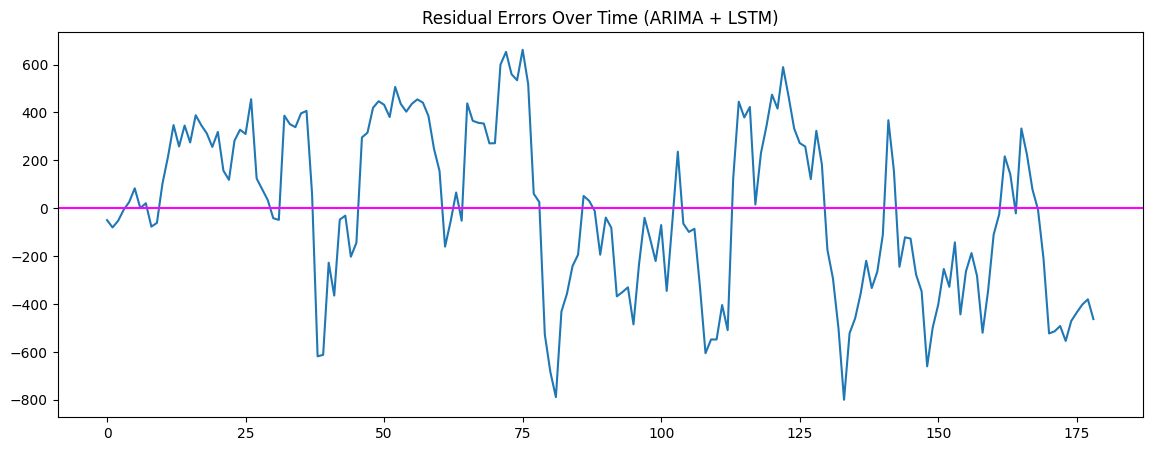

In [13]:
plt.figure(figsize=(14,5))
plt.plot(errors1)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='magenta')
plt.show()

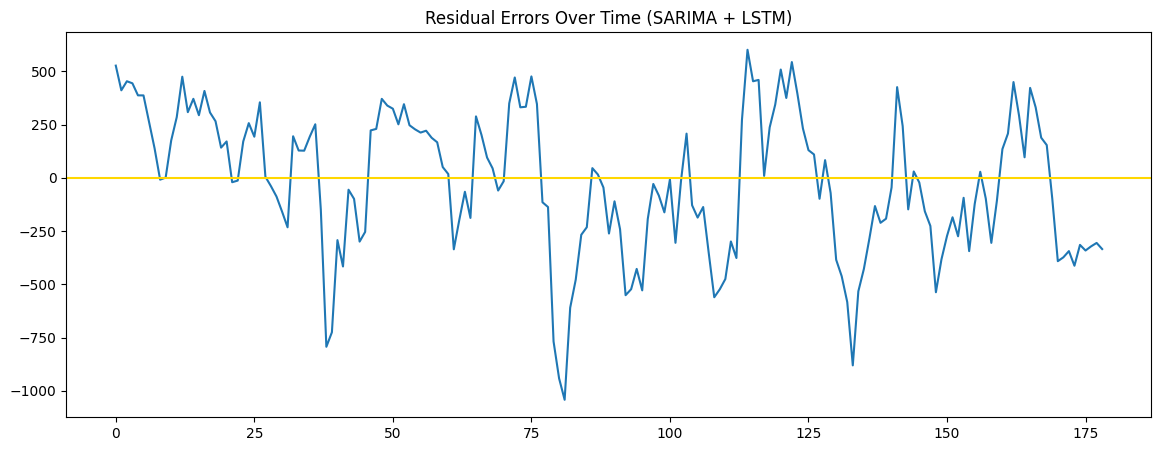

In [14]:
plt.figure(figsize=(14,5))
plt.plot(errors2)
plt.title("Residual Errors Over Time (SARIMA + LSTM)")
plt.axhline(0, color='gold')
plt.show()

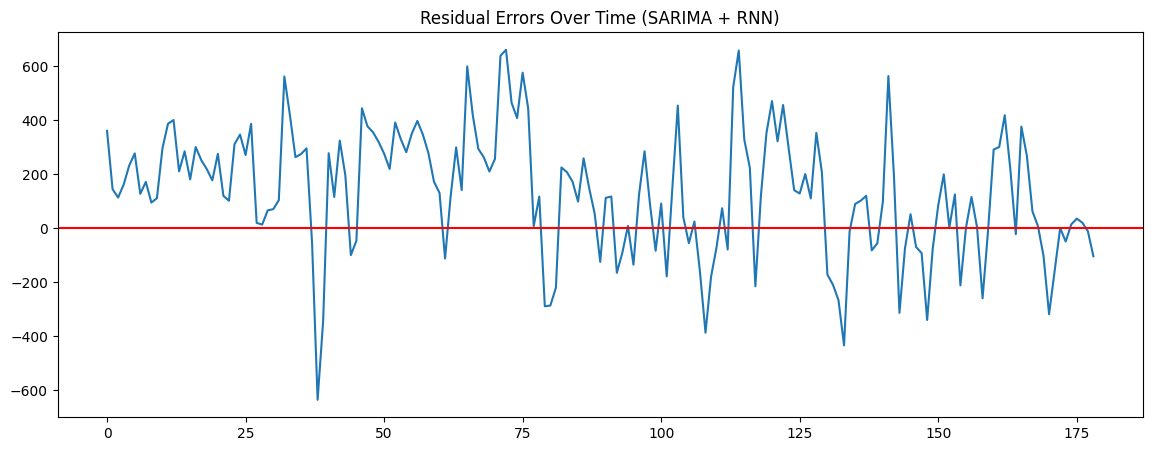

In [15]:
plt.figure(figsize=(14,5))
plt.plot(errors3)
plt.title("Residual Errors Over Time (SARIMA + RNN)")
plt.axhline(0, color='red')
plt.show()

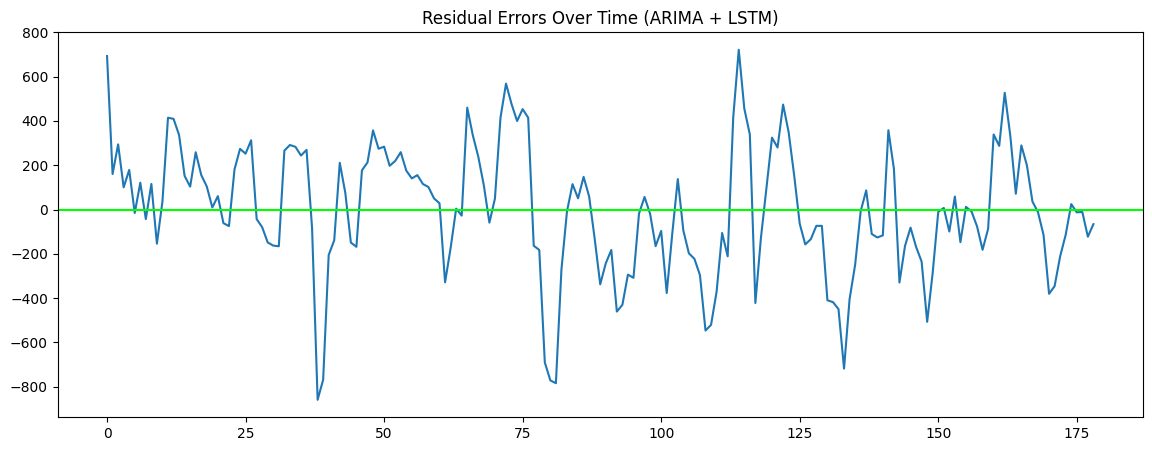

In [16]:
plt.figure(figsize=(14,5))
plt.plot(errors4)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='lime')
plt.show()

In [17]:
prediction_df = pd.DataFrame({
    "Actual": actual1,
    "Predicted_ARIMA_LSTM": final_arima_lstm
})

print(prediction_df.head())

     Actual  Predicted_ARIMA_LSTM
0  23259.20          23308.663022
1  23264.85          23344.984437
2  23322.95          23375.218376
3  23398.90          23405.461823
4  23465.60          23439.400644


In [18]:
prediction_df = pd.DataFrame({
    "Actual": actual2,
    "Predicted_SARIMA_LSTM": final_sarima_lstm
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_LSTM
0  23259.20           22732.669251
1  23264.85           22854.198296
2  23322.95           22869.734497
3  23398.90           22955.328392
4  23465.60           23078.570462


In [19]:
prediction_df = pd.DataFrame({
    "Actual": actual3.flatten(),
    "Predicted_RNN_LSTM": rnn_lstm_pred.flatten()
})

print(prediction_df.head())

     Actual  Predicted_RNN_LSTM
0  23259.20        22898.222656
1  23264.85        23120.031250
2  23322.95        23209.160156
3  23398.90        23237.097656
4  23465.60        23233.314453


In [20]:
prediction_df = pd.DataFrame({
    "Actual": actual4,
    "Predicted_SARIMA_RNN": final_sarima_rnn
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_RNN
0  23259.20          22566.549485
1  23264.85          23104.568414
2  23322.95          23028.924896
3  23398.90          23298.836205
4  23465.60          23287.058132


In [21]:
import numpy as np

def predict_future_prices(model, last_data, scaler, time_steps, future_days):
    
    # Ensure correct shape
    input_seq = last_data[-time_steps:]
    input_seq = input_seq.reshape(1, time_steps, 1)

    future_predictions = []

    for _ in range(future_days):
        
        pred = model.predict(input_seq, verbose=0)
        
        # Store prediction
        future_predictions.append(pred[0, 0])
        
        # Reshape prediction properly to (1,1,1)
        pred_reshaped = pred.reshape(1, 1, 1)
        
        # Remove first timestep and append prediction
        input_seq = np.concatenate(
            (input_seq[:, 1:, :], pred_reshaped),
            axis=1
        )

    # Convert back to original scale
    future_predictions = scaler.inverse_transform(
        np.array(future_predictions).reshape(-1, 1)
    )

    return future_predictions.flatten()

In [22]:
future_days = 10

future_prices = predict_future_prices(
    model3,
    test_scaled,
    scaler,
    time_steps,
    future_days
)

print("Future Prices:", future_prices)

Future Prices: [22843.336 22810.146 22769.467 22743.61  22726.752 22694.676 22666.877
 22643.29  22612.643 22582.69 ]


In [23]:
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=future_days+1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices
})

print(future_df)

        Date  Predicted_Price
0 2025-02-22     22843.335938
1 2025-02-23     22810.146484
2 2025-02-24     22769.466797
3 2025-02-25     22743.609375
4 2025-02-26     22726.751953
5 2025-02-27     22694.675781
6 2025-02-28     22666.876953
7 2025-03-01     22643.289062
8 2025-03-02     22612.642578
9 2025-03-03     22582.689453


#### Final Training & Comparison

In [24]:
time_steps = 30

# --- SARIMA ---
sarima_model = SARIMAX(train['Close'],
                       order=(4,0,3),
                       seasonal_order=(1,0,1,5))

sarima_result = sarima_model.fit()

forecast = sarima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - forecast.values
residuals = residuals.reshape(-1,1)

# --- Scaling ---
from sklearn.preprocessing import StandardScaler
scaler_res = StandardScaler()
res_scaled = scaler_res.fit_transform(residuals)

X_res, y_res = create_sequences(res_scaled, time_steps)

# --- RNN ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    SimpleRNN(61, return_sequences=True, input_shape=(time_steps,1)),
    Dropout(0.2),
    SimpleRNN(32),
    Dense(1)
])

model.compile(optimizer=Adam(0.0005), loss='huber')

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

model.fit(X_res, y_res,
          epochs=150,
          batch_size=16,
          callbacks=[early_stop],
          verbose=0)

# --- Prediction ---
pred = model.predict(X_res)
pred = scaler_res.inverse_transform(pred)

final_pred = forecast[time_steps:].values + pred.flatten()
actual = test['Close'].values[time_steps:]

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

6/6 [==============================] - 0s 3ms/step


In [25]:
# Evaludate Properly 
metrics_opt, _ = evaluate_model_advanced(actual, final_pred, "PSO SARIMA+RNN")


===== PSO SARIMA+RNN =====
RMSE : 87.46991640450013
MAE  : 67.63248287913429
R2   : 0.9869571422879849
MAPE : 0.27804864627416215
Actual Volatility : 0.007715153327842793
Predicted Volatility : 0.0067137649021469965
Accuracy : 0.7619047619047619
Precision: 0.7411764705882353
Recall   : 0.7777777777777778
F1 Score : 0.7590361445783133
Confusion Matrix:
 [[65 22]
 [18 63]]


In [26]:
final_results = pd.DataFrame([
    metrics1,   # ARIMA+LSTM
    metrics2,   # SARIMA+LSTM
    metrics3,   # RNN+LSTM
    metrics4,   # OLD SARIMA+RNN
    metrics_opt # NEW PSO SARIMA+RNN
])

print(final_results.sort_values("RMSE"))

            Model        RMSE         MAE        R2      MAPE  \
4  PSO SARIMA+RNN   87.469916   67.632483  0.986957  0.278049   
2      RNN + LSTM  264.528662  216.627774  0.881906  0.886406   
3    SARIMA + RNN  287.474223  225.584858  0.860530  0.928585   
1   SARIMA + LSTM  331.218982  273.152162  0.814854  1.129950   
0    ARIMA + LSTM  344.170622  291.746819  0.800091  1.202875   

   Actual_Volatility  Predicted_Volatility  Accuracy  Precision    Recall  \
4           0.007715              0.006714  0.761905   0.741176  0.777778   
2           0.007542              0.004436  0.544944   0.541667  0.584270   
3           0.007542              0.005441  0.561798   0.560440  0.573034   
1           0.007542              0.003177  0.556180   0.553191  0.584270   
0           0.007542              0.002138  0.578652   0.574468  0.606742   

   F1_Score  
4  0.759036  
2  0.562162  
3  0.566667  
1  0.568306  
0  0.590164  


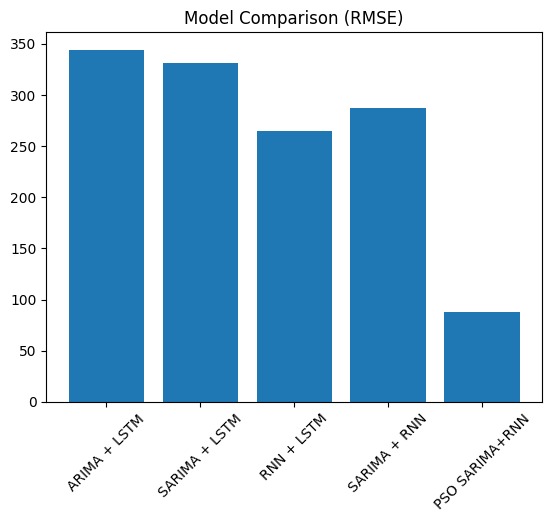

In [27]:
import matplotlib.pyplot as plt

plt.bar(final_results['Model'], final_results['RMSE'])
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.show()

In [28]:
future_days = 10  # no of days for prediction

future_prices = predict_future_prices(
    model,
    test_scaled,
    scaler,
    time_steps,
    future_days
)

print("Future Prices:", future_prices)

Future Prices: [23678.555 24532.78  25613.043 27093.607 28659.432 30150.951 31616.08
 32455.592 32574.473 31954.336]


In [29]:
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=future_days+1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices
})

print(future_df)

        Date  Predicted_Price
0 2025-02-22     23678.554688
1 2025-02-23     24532.779297
2 2025-02-24     25613.042969
3 2025-02-25     27093.607422
4 2025-02-26     28659.431641
5 2025-02-27     30150.951172
6 2025-02-28     31616.080078
7 2025-03-01     32455.591797
8 2025-03-02     32574.472656
9 2025-03-03     31954.335938
